In [ ]:
# 0. Install dan import
!pip install -q transformers datasets accelerate sentencepiece scikit-learn huggingface_hub

import json
import os
import random
import re
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)


In [ ]:
# 1. Config
@dataclass
class Config:
    dataset_dir_candidates: Tuple[str, ...] = (
        "dataset",
        "/content/Berita_Hoax_BERTopic/dataset",
        "/content/dataset",
    )
    file_cnn: str = "data_nonhoaks_cnn.csv"
    file_detik: str = "data_nonhoaks_detik.csv"
    file_kompas: str = "data_nonhoaks_kompas.csv"
    file_tbh: str = "data_hoaks_turnbackhoaks.csv"

    model_name: str = "indolem/indobert-base-uncased"
    text_priority: Tuple[str, ...] = ("summary", "Clean Narasi", "Narasi", "isi_berita", "judul")
    max_length: int = 256
    train_batch_size: int = 16
    eval_batch_size: int = 32
    grad_accumulation: int = 4
    learning_rate: float = 2e-5
    weight_decay: float = 0.01
    num_epochs: int = 3
    seed: int = 42
    balance_minority: bool = True
    auto_find_batch_size: bool = True
    gradient_checkpointing: bool = True
    early_stopping_patience: int = 2
    logging_steps: int = 50
    eval_accumulation_steps: int = 8
    dataloader_num_workers: int = 2
    output_dir: str = "indobert_hoax_model_v3"


cfg = Config()
set_seed(cfg.seed)
random.seed(cfg.seed)
np.random.seed(cfg.seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    torch.cuda.empty_cache()
print("Using device:", device)


In [ ]:
# 2. Validasi dataset lokal

def resolve_dataset_dir(cfg: Config) -> Path:
    candidates = [Path(candidate) for candidate in cfg.dataset_dir_candidates]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Tidak menemukan folder dataset. Candidates: {candidates}")


DATASET_DIR = resolve_dataset_dir(cfg)
DATASET_FILES = {
    "cnn": DATASET_DIR / cfg.file_cnn,
    "detik": DATASET_DIR / cfg.file_detik,
    "kompas": DATASET_DIR / cfg.file_kompas,
    "turnbackhoax": DATASET_DIR / cfg.file_tbh,
}

print("Dataset dir:", DATASET_DIR)
for source_name, path in DATASET_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"File dataset tidak ditemukan untuk {source_name}: {path}")
    print(f"[OK] {source_name}: {path}")


In [ ]:
# 3. data loading dan helpers
BASE_COLS = [
    "url",
    "judul",
    "tanggal",
    "isi_berita",
    "Narasi",
    "Clean Narasi",
    "hoax",
    "summary",
]


def load_single_dataset(path: Path, source_name: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File tidak ditemukan: {path}")

    print(f"\nMembaca: {path} (source={source_name})")
    df = pd.read_csv(path)
    print("  Kolom:", list(df.columns))
    print("  Jumlah baris:", len(df))

    for col in BASE_COLS:
        if col not in df.columns:
            df[col] = "" if col != "hoax" else np.nan

    df = df[BASE_COLS].copy()
    df["source"] = source_name
    return df


def load_all_datasets() -> pd.DataFrame:
    frames: List[pd.DataFrame] = []
    for source_name, path in DATASET_FILES.items():
        frames.append(load_single_dataset(path, source_name))

    merged = pd.concat(frames, ignore_index=True)
    print("\nTotal rows (raw merged):", len(merged))
    return merged


In [ ]:
# 4. preprocessing dan labeling

def build_training_dataframe(df_raw: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    df = df_raw.copy()

    def pick_text_and_source(row):
        for col in cfg.text_priority:
            val = row.get(col, "")
            if isinstance(val, str) and val.strip():
                return val.strip(), col
        return "", "UNKNOWN"

    picked = df.apply(pick_text_and_source, axis=1, result_type="expand")
    df["text"] = picked[0]
    df["text_source"] = picked[1]
    df["text"] = df["text"].astype(str).str.strip()

    before_empty = len(df)
    df = df[df["text"] != ""].reset_index(drop=True)
    print(f"Baris tanpa teks dibuang: {before_empty - len(df)}")

    df["hoax_num"] = pd.to_numeric(df["hoax"], errors="coerce")
    mask_nan = df["hoax_num"].isna()
    df.loc[(df["source"].isin(["cnn", "detik", "kompas"])) & mask_nan, "hoax_num"] = 0
    df.loc[(df["source"] == "turnbackhoax") & mask_nan, "hoax_num"] = 1

    before_nan = len(df)
    df = df[df["hoax_num"].isin([0, 1])].reset_index(drop=True)
    print(f"Baris dengan label hoax NaN dibuang: {before_nan - len(df)}")

    df["label"] = df["hoax_num"].astype(int)
    df = df.drop(columns=["hoax_num"])

    before_dupes = len(df)
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    print(f"Baris duplikat (text+label) dibuang: {before_dupes - len(df)}")

    print("\nDistribusi label (0=fakta, 1=hoaks):")
    print(df["label"].value_counts(normalize=False).sort_index())
    print("\nDistribusi label per source:")
    print(df.groupby("source")["label"].value_counts().unstack(fill_value=0))
    print("\nKolom teks terpilih:")
    print(df["text_source"].value_counts())

    return df


In [ ]:
# 4. Split train / val / test / balacing
def stratified_splits(df: pd.DataFrame, seed: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    70% train, 15% val, 15% test dengan stratify.
    """
    train_df, temp_df = train_test_split(
        df,
        test_size=0.30,
        stratify=df["label"],
        random_state=seed,
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df["label"],
        random_state=seed,
    )

    print("\nSplit sizes:")
    print("  Train:", len(train_df))
    print("  Val  :", len(val_df))
    print("  Test :", len(test_df))

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def balance_minority_only_train(train_df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    """
    Oversampling kelas minoritas di TRAIN saja.
    """
    counts = train_df["label"].value_counts()
    print("\nDistribusi TRAIN sebelum balancing:")
    print(counts)

    if len(counts) != 2:
        print("Label tidak biner atau hanya satu kelas, balancing dilewati.")
        return train_df

    max_count = counts.max()
    frames = []
    for label_val, df_label in train_df.groupby("label"):
        if len(df_label) < max_count:
            df_label = resample(
                df_label,
                replace=True,
                n_samples=max_count,
                random_state=seed,
            )
        frames.append(df_label)

    train_bal = pd.concat(frames, ignore_index=True)
    train_bal = train_bal.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    print("\nDistribusi TRAIN setelah balancing:")
    print(train_bal["label"].value_counts())
    return train_bal

In [ ]:
# login huggingface(masukkan token)
from huggingface_hub import login

login()

In [ ]:
# 5. Convert huggingface datasets dan tokenisasi
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=cfg.max_length,
    )


def prepare_datasets(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame):
    train_ds = Dataset.from_pandas(train_df[["text", "label", "source", "text_source"]], preserve_index=False)
    val_ds = Dataset.from_pandas(val_df[["text", "label", "source", "text_source"]], preserve_index=False)
    test_ds = Dataset.from_pandas(test_df[["text", "label", "source", "text_source"]], preserve_index=False)

    train_ds = train_ds.map(tokenize_batch, batched=True, desc="Tokenizing train")
    val_ds = val_ds.map(tokenize_batch, batched=True, desc="Tokenizing val")
    test_ds = test_ds.map(tokenize_batch, batched=True, desc="Tokenizing test")

    cols = ["input_ids", "attention_mask", "label"]
    train_ds.set_format(type="torch", columns=cols)
    val_ds.set_format(type="torch", columns=cols)
    test_ds.set_format(type="torch", columns=cols)

    return train_ds, val_ds, test_ds


In [ ]:
# 6. Model & setup training
label2id = {"Fakta": 0, "Hoaks": 1}
id2label = {v: k for k, v in label2id.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    cfg.model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)
model.config.use_cache = False
model.to(device)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if device == "cuda" else None,
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "f1_weighted": f1_w,
    }


training_kwargs = dict(
    output_dir=cfg.output_dir,
    overwrite_output_dir=True,
    per_device_train_batch_size=cfg.train_batch_size,
    per_device_eval_batch_size=cfg.eval_batch_size,
    gradient_accumulation_steps=cfg.grad_accumulation,
    num_train_epochs=cfg.num_epochs,
    learning_rate=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
    logging_steps=cfg.logging_steps,
    save_total_limit=2,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=cfg.gradient_checkpointing,
    auto_find_batch_size=cfg.auto_find_batch_size,
    eval_accumulation_steps=cfg.eval_accumulation_steps,
    dataloader_num_workers=cfg.dataloader_num_workers,
    report_to="none",
    seed=cfg.seed,
)

training_arg_names = set(TrainingArguments.__init__.__code__.co_varnames)
if "eval_strategy" in training_arg_names:
    training_kwargs["eval_strategy"] = "epoch"
elif "evaluation_strategy" in training_arg_names:
    training_kwargs["evaluation_strategy"] = "epoch"

training_kwargs = {k: v for k, v in training_kwargs.items() if k in training_arg_names}
training_args = TrainingArguments(**training_kwargs)

trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=None,
    eval_dataset=None,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=cfg.early_stopping_patience)],
)

trainer_arg_names = set(Trainer.__init__.__code__.co_varnames)
if "processing_class" in trainer_arg_names:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)


In [ ]:
# 7. pipeline end to end
df_raw = load_all_datasets()
df_all = build_training_dataframe(df_raw, cfg)

train_df, val_df, test_df = stratified_splits(df_all, seed=cfg.seed)

if cfg.balance_minority:
    train_df = balance_minority_only_train(train_df, seed=cfg.seed)

train_ds, val_ds, test_ds = prepare_datasets(train_df, val_df, test_df)

trainer.train_dataset = train_ds
trainer.eval_dataset = val_ds

train_result = trainer.train()
print("\nTraining selesai.")
print(train_result)

print("\n=== Evaluasi di VALIDATION set ===")
val_metrics = trainer.evaluate(val_ds)
print(val_metrics)

print("\n=== Evaluasi di TEST set ===")
test_metrics = trainer.evaluate(test_ds)
print(test_metrics)



--- Validation Classification Report ---
              precision    recall  f1-score   support

    not_hoax     0.9988    0.9994    0.9991     24640
        hoax     0.9921    0.9833    0.9877      1793

    accuracy                         0.9983     26433
   macro avg     0.9955    0.9914    0.9934     26433
weighted avg     0.9983    0.9983    0.9983     26433


--- Validation Confusion Matrix ---
[[24626    14]
 [   30  1763]]


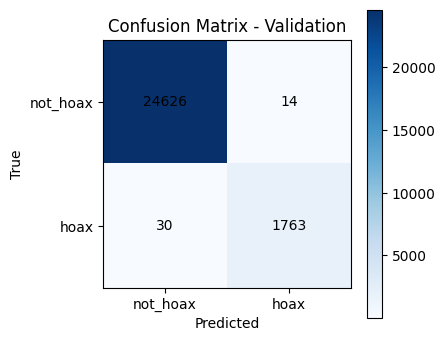


--- Test Classification Report ---
              precision    recall  f1-score   support

    not_hoax     0.9986    0.9996    0.9991     24641
        hoax     0.9938    0.9810    0.9874      1793

    accuracy                         0.9983     26434
   macro avg     0.9962    0.9903    0.9932     26434
weighted avg     0.9983    0.9983    0.9983     26434


--- Test Confusion Matrix ---
[[24630    11]
 [   34  1759]]


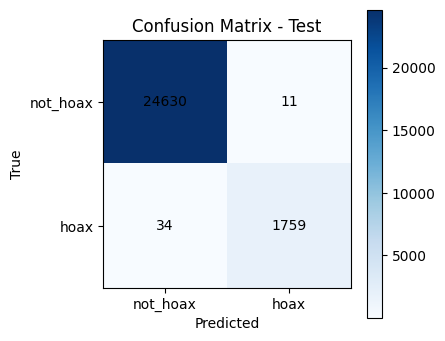

In [ ]:
# 8. Laporan detail
def detailed_report(trainer: Trainer, dataset: Dataset, split_name: str):
    preds_output = trainer.predict(dataset)
    y_true = preds_output.label_ids
    y_pred = np.argmax(preds_output.predictions, axis=-1)

    target_names = ["not_hoax", "hoax"]
    print(f"\n--- {split_name} Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    print(f"\n--- {split_name} Confusion Matrix ---")
    print(cm)

    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(target_names)
    ax.set_yticklabels(target_names)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
    plt.title(f"Confusion Matrix - {split_name}")
    plt.colorbar(im, ax=ax)
    plt.show()


detailed_report(trainer, val_ds, "Validation")
detailed_report(trainer, test_ds, "Test")

In [ ]:
# 9. Simpan model dan tokenizer
os.makedirs(cfg.output_dir, exist_ok=True)
trainer.save_model(cfg.output_dir)
tokenizer.save_pretrained(cfg.output_dir)
print(f"\nModel & tokenizer disimpan ke: {cfg.output_dir}")


In [ ]:
# 10. Uji multi paragraf per kalimat
PARAGRAPH_SPLIT_RE = re.compile(r"(?:\r?\n){2,}")
SENTENCE_RE = re.compile(r'[^.!?]+(?:[.!?]+(?:["”’)\]]+)?)|[^.!?]+$')


def split_paragraphs(text: str) -> List[str]:
    paragraphs = [p.strip() for p in PARAGRAPH_SPLIT_RE.split(str(text).strip()) if p.strip()]
    if paragraphs:
        return paragraphs
    raw = str(text).strip()
    return [raw] if raw else []


def split_sentences(paragraph: str) -> List[str]:
    normalized = re.sub(r"\s+", " ", str(paragraph)).strip()
    if not normalized:
        return []
    sentences = [match.group(0).strip() for match in SENTENCE_RE.finditer(normalized)]
    sentences = [sentence for sentence in sentences if sentence]
    return sentences or [normalized]


def predict_sentence_batch(sentences: List[str], batch_size: int = None) -> List[Dict[str, object]]:
    active_model = trainer.model if hasattr(trainer, "model") else model
    active_model.eval()
    rows: List[Dict[str, object]] = []
    batch_size = batch_size or min(cfg.eval_batch_size, 32)

    with torch.inference_mode():
        for start_idx in range(0, len(sentences), batch_size):
            batch = sentences[start_idx : start_idx + batch_size]
            encoded = tokenizer(
                batch,
                truncation=True,
                max_length=cfg.max_length,
                padding=True,
                pad_to_multiple_of=8 if device == "cuda" else None,
                return_tensors="pt",
            )
            encoded = {key: value.to(device) for key, value in encoded.items()}
            probs = torch.softmax(active_model(**encoded).logits, dim=-1).detach().cpu()
            pred_ids = probs.argmax(dim=-1).tolist()

            for sentence, pred_id, prob_tensor in zip(batch, pred_ids, probs):
                values = prob_tensor.tolist()
                prob_fakta = float(values[label2id["Fakta"]])
                prob_hoax = float(values[label2id["Hoaks"]])
                confidence = max(prob_fakta, prob_hoax)
                label = id2label[int(pred_id)]
                color = "orange" if confidence < 0.65 else ("red" if label == "Hoaks" else "green")
                rows.append(
                    {
                        "text": sentence,
                        "label": label,
                        "prob_fakta": round(prob_fakta, 6),
                        "prob_hoax": round(prob_hoax, 6),
                        "confidence": round(confidence, 6),
                        "color": color,
                    }
                )
    return rows


def analyze_multi_paragraph(text: str) -> Dict[str, object]:
    paragraphs_raw = split_paragraphs(text)
    counts: List[int] = []
    flat_sentences: List[str] = []
    for paragraph in paragraphs_raw:
        sentences = split_sentences(paragraph)
        counts.append(len(sentences))
        flat_sentences.extend(sentences)

    classified = predict_sentence_batch(flat_sentences)

    cursor = 0
    paragraph_rows = []
    total_hoax = 0
    total_fakta = 0
    for paragraph_index, sentence_count in enumerate(counts):
        sentence_rows = classified[cursor : cursor + sentence_count]
        cursor += sentence_count
        hoax_sentences = sum(1 for row in sentence_rows if row["label"] == "Hoaks")
        fakta_sentences = sum(1 for row in sentence_rows if row["label"] == "Fakta")
        total_hoax += hoax_sentences
        total_fakta += fakta_sentences
        paragraph_rows.append(
            {
                "paragraph_index": paragraph_index,
                "sentences": sentence_rows,
                "paragraph_summary": {
                    "hoax_sentences": hoax_sentences,
                    "fakta_sentences": fakta_sentences,
                },
            }
        )

    return {
        "summary": {
            "num_paragraphs": len(paragraph_rows),
            "num_sentences": len(classified),
            "hoax_sentences": total_hoax,
            "fakta_sentences": total_fakta,
        },
        "paragraphs": paragraph_rows,
    }


contoh_multi_paragraf = """Beredar unggahan yang mengklaim Kementerian Kehutanan membuka rekrutmen CPNS Polisi Kehutanan tahun 2026 secara besar-besaran. Unggahan itu mengarahkan masyarakat ke tautan pendaftaran tidak resmi.

PT Transjakarta melakukan modifikasi layanan pada empat rute mulai 21 Februari 2026 untuk meningkatkan kenyamanan penumpang. Penyesuaian dilakukan pada sebagian titik halte yang dilayani."""

hasil_demo = analyze_multi_paragraph(contoh_multi_paragraf)
print(json.dumps(hasil_demo, ensure_ascii=False, indent=2))


In [ ]:
# 11. Download model
import shutil
from google.colab import files

output_filename = f"{cfg.output_dir}.zip"

print(f"Membuat zip: {cfg.output_dir}...")
shutil.make_archive(cfg.output_dir, "zip", cfg.output_dir)

print(f"Mengunduh file: {output_filename}...")
files.download(output_filename)
print("Akhirnya siap!")
